In [98]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import norm
import matplotlib.pyplot as plt


Total PnL: 4.114066523826871
Theoretical PnL: 4.14987570359739


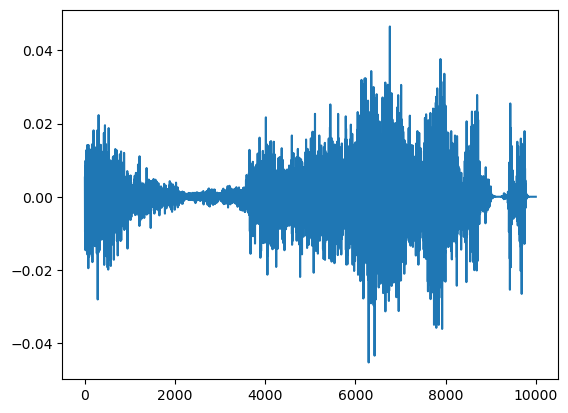

In [ ]:
# Vectorized (per-step) discrete-time delta hedging (pricing vol vs realized vol)
import numpy as np
from scipy.stats import norm

def simulate_delta_hedge_paths(
    S0=100.0,
    K=100.0,
    r=0,
    sigma_real=0.20,
    sigma_imp=0.1,
    T=1.0,
    n_steps=10000,  # number of hedge rebalances (time intervals). There will be n_steps price increments.
    n_paths=10000,
    seed=None,
    transaction_cost_bps=0.0,
):
    """Discrete delta hedging for a long European call (long option, dynamically hedged with underlying).

    This version corrects two issues common in ad-hoc implementations:
      1. Ensures EXACTLY n_steps price increments reaching maturity (previous draft missed final increment).
      2. Provides a cash-account P/L (self-financing) decomposition.

    Components returned now map as:
      payoff_component           = payoff - premium
      hedge_trading_component    = P/L from the short stock position
      financing_component        = cumulative interest accrued on cash account
      transaction_cost_component = negative cost impact (sum of costs)

    Net P/L identity (up to numerical noise & discretization):
        pnl  ≈ payoff_component + hedge_trading_component + financing_component + transaction_cost_component

    Parameters
    ----------
    sigma_real : float
        Used to generate the underlying path (realized vol).
    sigma_imp : float | None
        Used for pricing & deltas. If None defaults to sigma_real (pure replication test).
    transaction_cost_bps : float
        Proportional cost (bps of notional |Δ|*S) applied to every trade including initial hedge & final liquidation.
    n_steps : int
        Number of hedge intervals (there will be n_steps increments & n_steps re-hedges except none after maturity).

    """
    sigma_imp = sigma_real if sigma_imp is None else sigma_imp

    rng = np.random.default_rng(seed)
    dt = T / n_steps

    # Initial price & delta
    sqrt_T = np.sqrt(T)
    d1_0 = (np.log(S0 / K) + (r + 0.5 * sigma_imp**2) * T) / (sigma_imp * sqrt_T)
    d2_0 = d1_0 - sigma_imp * sqrt_T
    call_premium = S0 * norm.cdf(d1_0) - K * np.exp(-r * T) * norm.cdf(d2_0)
    # To hedge a long call (positive delta), we must short the underlying.
    # The stock position will therefore be negative.
    initial_delta_call = norm.cdf(d1_0)
    stock_qty = np.zeros(n_steps)
    drift = (r-0.5*sigma_real*sigma_real)
    stock_qty[0] = -initial_delta_call
    S = np.zeros(n_steps)
    S[0] = S0
    gamma = np.zeros(n_steps)
    gamma[0] = norm.pdf(d1_0)/(S0*sigma_imp*sqrt_T)
    cash_account = np.zeros(n_steps)
    cash_account[0] = -stock_qty[0] * S0
    for i in range(n_steps-1):
        S[i+1] = S[i] * np.exp(drift*dt + sigma_real * np.sqrt(dt) * np.random.standard_normal())
        T = T - dt
        d1_0 = (np.log(S[i+1] / K) + (r + 0.5 * sigma_imp**2) * T) / (sigma_imp * np.sqrt(T))
        delta_call = norm.cdf(d1_0)
        stock_qty[i+1] = -delta_call
        gamma[i+1] = norm.pdf(d1_0)/(S[i+1]*sigma_imp*np.sqrt(T))
        cash_account[i+1] = cash_account[i] * np.exp(r * dt) - (stock_qty[i+1] - stock_qty[i]) * S[i+1]
    payoff = max(S[-1] - K, 0)
    total_pnl = cash_account[-1] + stock_qty[-1] * S[-1] + payoff - call_premium
    return S, stock_qty, call_premium, gamma*dt, total_pnl, cash_account, stock_qty, S, payoff
S, stock_qty, call_premium, gamma, total_pnl , cash_account, stock_qty, S, payoff = simulate_delta_hedge_paths()
quantity_traded = np.diff(stock_qty)
plt.plot(quantity_traded)
pnl_theo = 0.5 * (0.2**2 - 0.1**2) * np.dot(S**2, gamma)
print(f"Total PnL: {total_pnl}")
print(f"Theoretical PnL: {pnl_theo}")

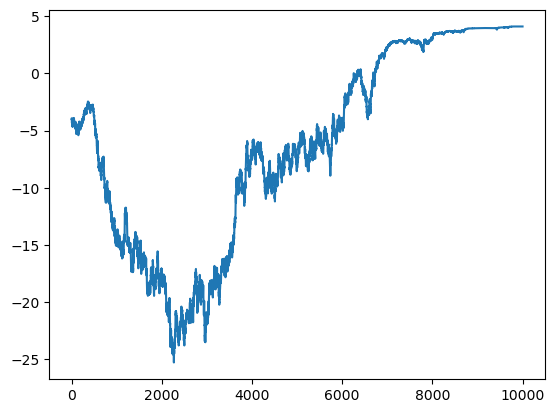

In [377]:
plt.plot(cash_account + stock_qty*S + payoff - call_premium)

# Gamma Scalping / Delta Hedging Diagnostics Plots

The next cells generate:
1. P/L distribution: replication (sigma_real = sigma_imp) vs mispricing (sigma_real > sigma_imp).
2. Component mean bar chart: payoff-premium, hedge trading, financing, transaction costs.
3. Re-hedge frequency sweep: effect of number of steps on mean P/L and average transaction cost.

Adjust parameters at the top of the data prep cell to explore scenarios (vols, costs, paths).

In [90]:
# Scenario parameters (aligned with basic_options replication example)
S0 = 100.0
K = 100.0
r = 0
T = 1.0
sigma_replication = 1.0  # both realized & implied
# Disable mispricing by setting mis vols equal (will skip plotting mispricing unless changed later)
sigma_real_mis = sigma_replication
sigma_imp_mis = sigma_replication
transaction_cost_bps = 0
n_paths = 10000
n_steps = 10000  # match basic_options n
seed = 12345  # fixed seed for reproducibility

# Replication (no mispricing)
rep = simulate_delta_hedge_paths(
    S0=S0, K=K, r=r, sigma_real=sigma_real_mis, sigma_imp=sigma_imp_mis,
    T=T, n_steps=n_steps, n_paths=n_paths, seed=seed, transaction_cost_bps=transaction_cost_bps
)

rep_mean_pnl = rep['pnl'].mean()

print(f"Replication mean P/L (should be near 0): {rep_mean_pnl:.6f}")
print(f"Replication std: {rep['pnl'].std():.6f}")

Replication mean P/L (should be near 0): 0.003710
Replication std: 0.324654


#### 1. The P/L of an Idealized *Long* Call Portfolio (Continuous Time)

Let's analyze a portfolio, $\Pi$, that is **long one call option** and is hedged by shorting $\Delta$ shares of the stock.
$$
\Pi = C - \Delta S
$$
The change in this portfolio's value over an infinitesimal time step, $dt$, is:
$$
d\Pi = dC - \Delta dS
$$
This equation tracks the change in value of the assets we *already hold*. Using the Taylor expansion for $dC$ ($dC = \Delta dS + \Theta dt + \frac{1}{2} \Gamma (dS)^2$), we get:
$$
d\Pi = (\Delta dS + \Theta dt + \frac{1}{2} \Gamma (dS)^2) - \Delta dS
$$
$$
d\Pi = \Theta dt + \frac{1}{2} \Gamma (dS)^2
$$
This is the P/L from the existing position, often called the "gamma-theta" P/L. Now, we use the Black-Scholes PDE relationship, which dictates that for the option to be fairly priced (with $r=0$), the time decay must offset the expected gamma earnings: $\Theta = -\frac{1}{2} \sigma_{\text{imp}}^2 S^2 \Gamma$. Substituting this in:
$$
d\Pi = \left(-\frac{1}{2} \sigma_{\text{imp}}^2 S^2 \Gamma\right) dt + \frac{1}{2} \Gamma (dS)^2
$$
Factoring out terms gives the famous result:
$$
d\Pi = \frac{1}{2} \Gamma S^2 \left( \left(\frac{dS}{S}\right)^2 - \sigma_{\text{imp}}^2 dt \right)
$$
In the continuous world, the instantaneous variance $(\frac{dS}{S})^2$ is defined as $\sigma_{\text{real}}^2 dt$. So, the P/L of the idealized portfolio is:
$$
d\Pi = \frac{1}{2} \Gamma S^2 (\sigma_{\text{real}}^2 - \sigma_{\text{imp}}^2) dt
$$
This equation shows that if $\sigma_{\text{real}} = \sigma_{\text{imp}}$, the P/L of a continuously hedged portfolio should be exactly zero.

In [91]:
sigma_imp_mis = 0.2
sigma_real_mis = 0.2

mis = simulate_delta_hedge_paths(
    S0=S0, K=K, r=r, sigma_real=sigma_real_mis, sigma_imp=sigma_imp_mis,
    T=T, n_steps=n_steps, n_paths=n_paths, seed=seed+1 if seed is not None else None, transaction_cost_bps=transaction_cost_bps
)
component_means_mis = {
    'payoff-premium': mis['payoff_component'].mean(),
    'financing': mis['financing_component'].mean(),
    'tx_costs': mis['transaction_cost_component'].mean(),
    'net': mis['pnl'].mean(),
}

In [92]:
component_means_mis

{'payoff-premium': np.float64(-0.22690738252923529),
 'financing': np.float64(0.0),
 'tx_costs': np.float64(0.0),
 'net': np.float64(-0.0002381046073067922)}

In [93]:
# Raw histogram using Plotly
mean_pnl = rep['pnl'].mean()
fig = px.histogram(
    rep,
    x='pnl',
    nbins=n_paths//10,
    histnorm='probability density',
    title='Replication Net P/L (Full Range)',
    labels={'pnl': 'Net P/L'},
    opacity=0.65
)
fig.add_vline(
    x=mean_pnl,
    line_dash="dash",
    line_color="black",
    annotation_text=f"mean={mean_pnl:.4f}",
    annotation_position="top right"
)
fig.update_layout(
    width=600,
    height=400,
    showlegend=False
)
fig.show()

In [94]:
# Bar chart of mean component contributions (mispricing scenario) using Plotly
means = component_means_mis
labels = list(means.keys())
vals = list(means.values())

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=vals,
    text=[f'{v:.2f}' for v in vals],
    textposition='auto',
    marker_color=['green' if v > 0 else 'red' for v in vals]
)])

fig.update_layout(
    title='Mean P/L Component Contributions (Mispricing)',
    width=600,
    height=400,
    xaxis_title="Component",
    yaxis_title="Mean P/L"
)
fig.show()

In [95]:
# Re-hedge frequency sweep (mispricing scenario) using Plotly
from plotly.subplots import make_subplots

frequencies = [50, 100, 150, 250, 400, 600]
mean_pnl = []
mean_cost = []
for steps in frequencies:
    sweep_res = simulate_delta_hedge_paths(
        S0=S0, K=K, r=r, sigma_real=sigma_real_mis, sigma_imp=sigma_imp_mis,
        T=T, n_steps=steps, n_paths=15000, seed=999, transaction_cost_bps=transaction_cost_bps
    )
    mean_pnl.append(sweep_res['pnl'].mean())
    mean_cost.append(sweep_res['transaction_cost_component'].mean())

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(
    go.Scatter(x=frequencies, y=mean_pnl, name="Mean P/L", mode='lines+markers'),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=frequencies, y=mean_cost, name="Mean Tx Costs", mode='lines+markers'),
    secondary_y=True,
)

# Add figure title
fig.update_layout(
    title_text="Re-hedge Frequency Impact (Mispricing)",
    width=700,
    height=400
)

# Set x-axis title
fig.update_xaxes(title_text="Number of hedge steps")

# Set y-axes titles
fig.update_yaxes(title_text="Mean P/L", secondary_y=False)
fig.update_yaxes(title_text="Mean Transaction Costs", secondary_y=True)

fig.show()